In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Importing necessary modules
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from RL4CRN.utils.utils import print_task_info
from RL4CRN.iocrns.mass_action_iocrn import MassActionIOCRN

In [3]:
# Construct using the stoichiometry matrices and parameters
species_labels = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs_labels = ['u_1', 'u_2', 'u_3']
S_R = np.array([[1, 1, 0, 0, 0, 0, 0, 0, 0], 
                [0, 0, 1, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 1, 1, 1, 0],
                [0, 0, 0, 0, 0, 1, 0, 0, 1]], dtype=np.int8)
S_P = np.array([[0, 1, 0, 0, 0, 0, 1, 0, 0], 
                [0, 1, 0, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 1, 0, 0, 1, 0, 0],
                [0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=np.int8)
gamma_1 = 5.0; k_1 = 1.0; gamma_2 = 0.5; mu = 10.0; theta = 1.0; eta = 0.1; k = 1.0; delta = 0.01
c = np.array([gamma_1, k_1, gamma_2, mu, theta, eta, k, delta, delta], dtype=np.float32)
S_I = np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0], 
                [1, 0, 0, 0, 0, 0, 0, 0, 0], 
                [0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=np.int8)
o = np.array([1, 2], dtype=np.int8)
iocrn_0 = MassActionIOCRN(S_R, S_P, c, S_I, o, species_labels, inputs_labels)

In [4]:
# Print the constructed IOCRN
print(iocrn_0)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_1', 'X_2'] 
Reaction 0: X_1 -> 0 ; Rate Constant: 5.0u_2 
Reaction 1: X_1 -> X_1 + X_2 ; Rate Constant: 1.0 
Reaction 2: X_2 -> 0 ; Rate Constant: 0.5u_3 
Reaction 3: 0 -> Z_1 ; Rate Constant: 10.0u_1 
Reaction 4: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0 
Reaction 5: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612 
Reaction 6: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0 
Reaction 7: Z_1 -> 0 ; Rate Constant: 0.009999999776482582 
Reaction 8: Z_2 -> 0 ; Rate Constant: 0.009999999776482582 



type --- Type: str, Value: transient response
inputs --- Type: list of numpy arrays, List size: 27, Numpy Arrays shape: (3,)
initial conditions --- Type: list of numpy arrays, List size: 1, Numpy Arrays shape: (4,)
time_horizon --- Type: ndarray, Shape: (1000,)
trajectories --- Type: list of numpy arrays, List size: 27, Numpy Arrays shape: (4, 1000)
outputs --- Type: list of numpy arrays, List size: 27, Numpy Arrays shape: (2, 1000)


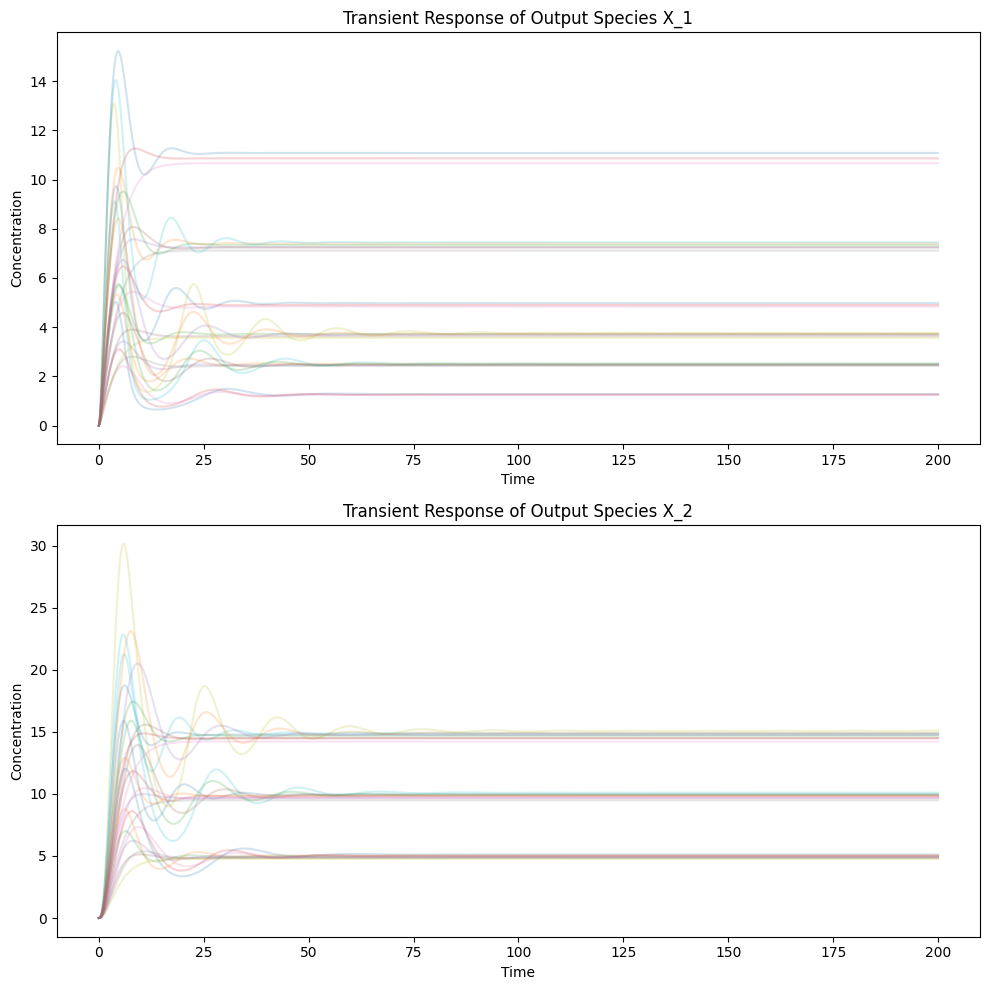

In [5]:
# Simulate Dynamics
input_values = [0.5, 1, 1.5]
u_list = [np.array(u, dtype=np.float32) for u in product(input_values, repeat=iocrn_0.p)]
x0_list = [np.array([0, 0, 0, 0], dtype=np.float32)]
time_horizon = np.linspace(0, 200, 1000, dtype=np.float32)
t, x_list, y_list, transients_task_info = iocrn_0.transient_response(u_list, x0_list, time_horizon)
iocrn_0.print_task_info('sizes')
# Plot using class method
fig, ax = iocrn_0.plot_transient_response(alpha = 0.2)

type --- Type: str, Value: dose response
input doses --- Type: ndarray, Shape: (100,)
input scenarios --- Type: list of numpy arrays, List size: 9, Numpy Arrays shape: (2,)
states --- Type: list of numpy arrays, List size: 9, Numpy Arrays shape: (4, 100)
outputs --- Type: list of numpy arrays, List size: 9, Numpy Arrays shape: (2, 100)


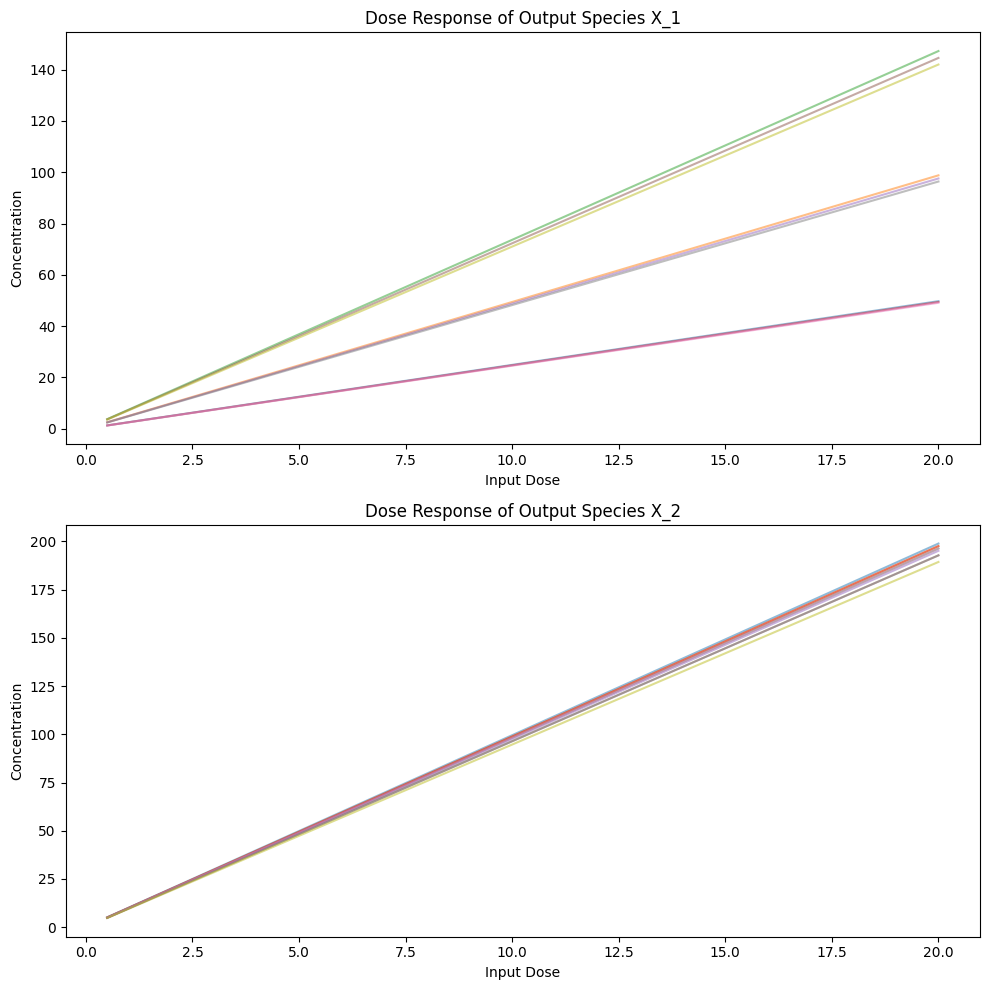

In [6]:
# Simulate Dose Responses
u_dose = np.linspace(0.5, 20, 100, dtype=np.float32)
u_dose_list = [np.array(u, dtype=np.float32) for u in product(input_values, repeat=iocrn_0.p-1)]
initial_guess = np.array([0.01, 0.01, 0.01, 0.01], dtype=np.float32)
x_ss_list, y_ss_list, dose_task_info = iocrn_0.dose_response(u_dose, u_dose_list, initial_guess)
iocrn_0.print_task_info('sizes')
# Plot using class method
fig, ax = iocrn_0.plot_dose_response(alpha = 0.5)

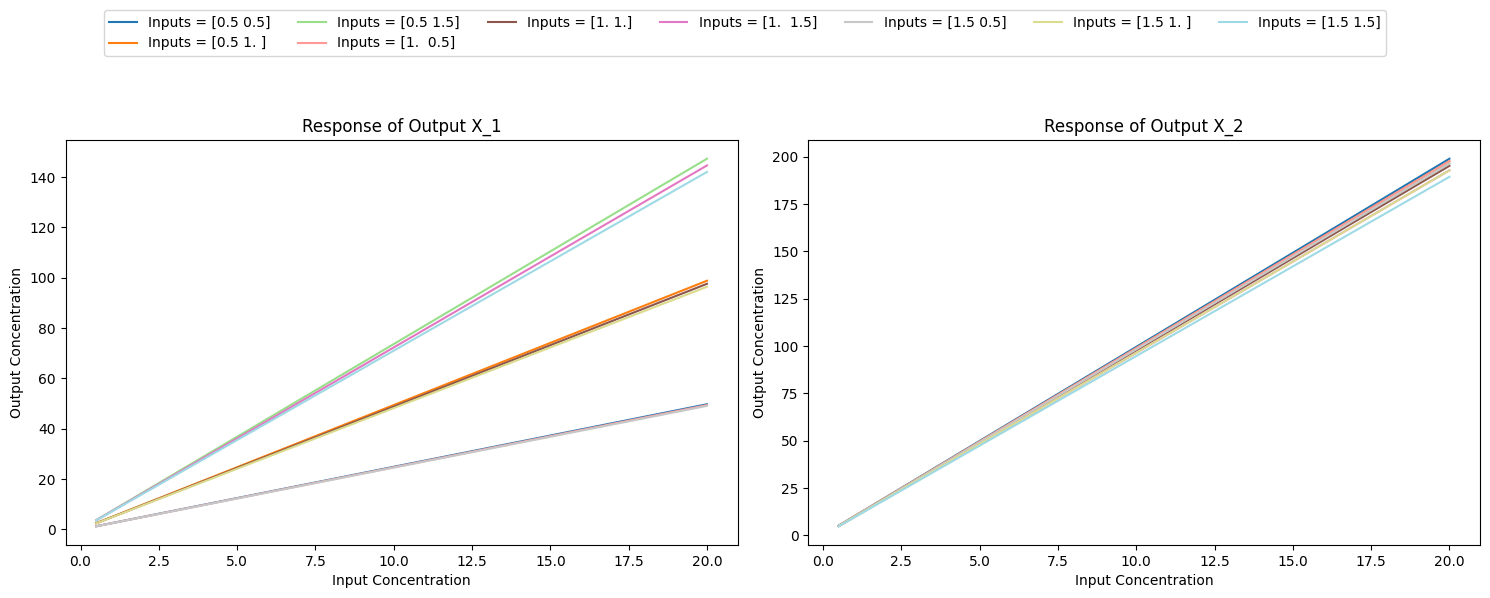

In [7]:
# Plot the output dose responses
colors = plt.colormaps['tab20'].resampled(len(u_dose_list)) # or 'tab20', 'hsv', 'plasma'
fig, ax = plt.subplots(1, iocrn_0.q, figsize=(15, 5))
for i in range(iocrn_0.q):
    for j in range(len(u_dose_list)):
        ax[i].plot(u_dose, y_ss_list[j][i,:], label=f'Inputs = {u_dose_list[j]}', color=colors(j))
    ax[i].set_title(f"Response of Output {iocrn_0.species_labels[iocrn_0.o[i]-1]}")
    ax[i].set_xlabel('Input Concentration')
    ax[i].set_ylabel('Output Concentration')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.2))
plt.tight_layout()
plt.show()

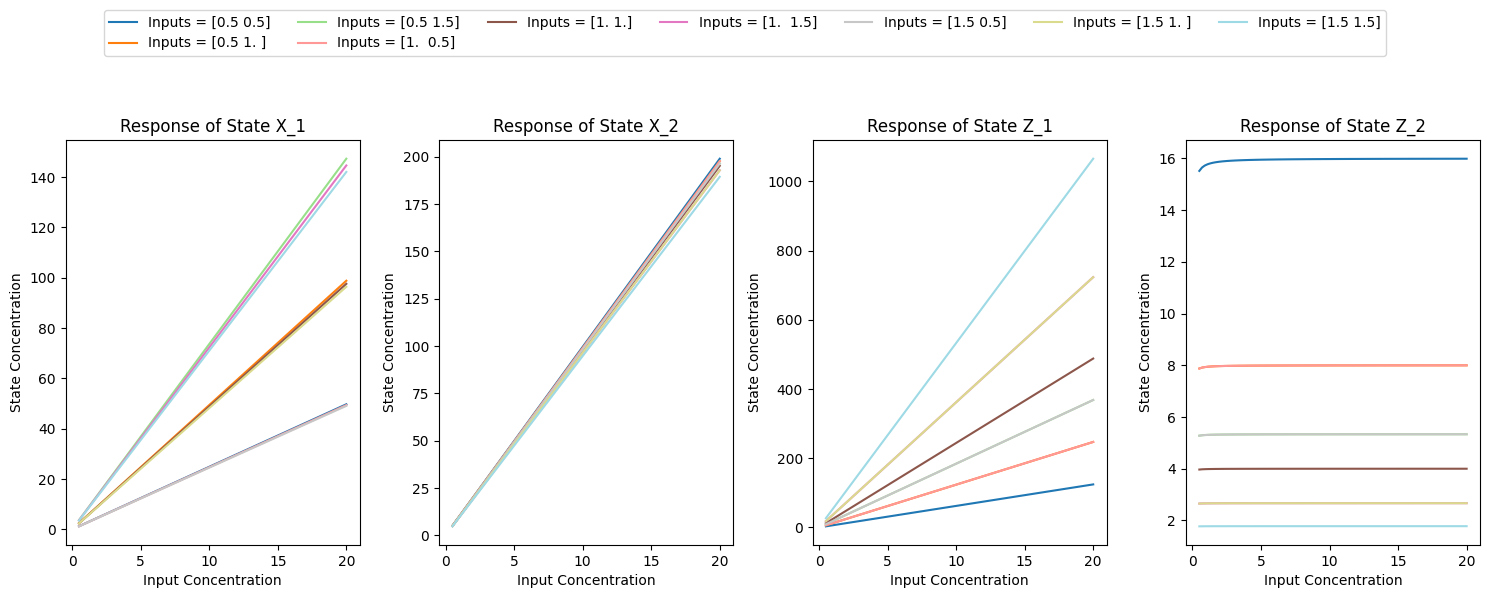

In [8]:
# Plot the state dose responses
fig, ax = plt.subplots(1, iocrn_0.n, figsize=(15, 5))
for i in range(iocrn_0.n):
    for j in range(len(u_dose_list)):
        ax[i].plot(u_dose, x_ss_list[j][i,:], label=f'Inputs = {u_dose_list[j]}', color=colors(j))
    ax[i].set_title(f"Response of State {iocrn_0.species_labels[i]}")
    ax[i].set_xlabel('Input Concentration')
    ax[i].set_ylabel('State Concentration')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.2))
plt.tight_layout()
plt.show()

In [10]:
# Tasks Information
print_task_info(transients_task_info, 'sizes')
print('--'*50)
print_task_info(dose_task_info, 'sizes')

type --- Type: str, Value: transient response
inputs --- Type: list of numpy arrays, List size: 27, Numpy Arrays shape: (3,)
initial conditions --- Type: list of numpy arrays, List size: 1, Numpy Arrays shape: (4,)
time_horizon --- Type: ndarray, Shape: (1000,)
trajectories --- Type: list of numpy arrays, List size: 27, Numpy Arrays shape: (4, 1000)
outputs --- Type: list of numpy arrays, List size: 27, Numpy Arrays shape: (2, 1000)
----------------------------------------------------------------------------------------------------
type --- Type: str, Value: dose response
input doses --- Type: ndarray, Shape: (100,)
input scenarios --- Type: list of numpy arrays, List size: 9, Numpy Arrays shape: (2,)
states --- Type: list of numpy arrays, List size: 9, Numpy Arrays shape: (4, 100)
outputs --- Type: list of numpy arrays, List size: 9, Numpy Arrays shape: (2, 100)
